Exercise 10.1

In [32]:
from random import randrange

print(randrange(1,7))
print(randrange(1,7))

6
2


In [37]:
n = 0 #number of times we get a double six
for i in range(1000000):
    x = randrange(1,7)
    y = randrange(1,7)
    if x==6 and y==6:
        n += 1
print(n/1e6)

0.027656


In [36]:
1/36

0.027777777777777776

Exercise 10.2: Radioactive decay chain

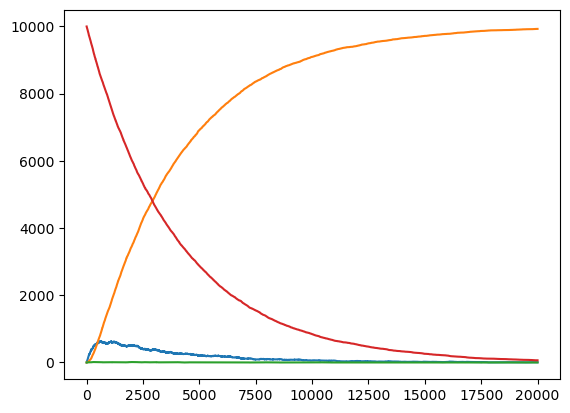

In [17]:
from random import random
import numpy as np
import matplotlib.pyplot as plt

#Constants
NPb_209 = 0
NBi_209 = 0
NTl_209 = 0
NBi_213 = 10000
tau1 = 3.3*60
tau2 = 2.2*60
tau3 = 46.0*60
h = 1.0
p1 = 1 - 2**(-h/tau1)
p2 = 1 - 2**(-h/tau2)
p3 = 1 - 2**(-h/tau3)
tmax = 20000

#List of plot points
tpoints = np.arange(0.0,tmax,h)
Pb_209points = []
Bi_209points = []
Tl_209points = []
Bi_213points = []

#Main loop
for t in tpoints:
    Pb_209points.append(NPb_209)
    Bi_209points.append(NBi_209)
    Tl_209points.append(NTl_209)
    Bi_213points.append(NBi_213)
    
    decay = 0
    for i in range(NPb_209):
        if random()<p1:
            decay += 1
    NPb_209 -= decay
    NBi_209 += decay
    
    decay = 0
    for i in range(NTl_209):
        if random()<p2:
            decay += 1
    NTl_209 -= decay
    NPb_209 += decay
    
    decay1 = 0
    decay2 = 0
    for i in range(NBi_213):
        if random()<p3:
            if random()<0.9791:
                decay1 += 1
            else:
                decay2 += 1
    NBi_213 -= decay1
    NPb_209 += decay1
    NBi_213 -= decay2
    NTl_209 += decay2
    
plt.plot(tpoints, Pb_209points)
plt.plot(tpoints, Bi_209points)
plt.plot(tpoints, Tl_209points)
plt.plot(tpoints, Bi_213points)

Exercise 10.3: Brownian motion

In [2]:
import random as rd

L = 101 

i,j = int(L//2 + 1),int(L//2 + 1)

for n in range(1000000):
    vp.rate(10)
    r = rd.random()
    if i==0:
        if j==0:
            if r<0.5:
                i += 1
            else:
                j += 1
        elif j==L-1:
            if r<0.5:
                i += 1
            else:
                j -= 1
        else:
            if r< 1/3:
                i += 1
            elif r<2/3:
                j += 1
            else:
                j -= 1
    elif i==L-1:
        if j==0:
            if r<0.5:
                i -= 1
            else:
                j += 1
        elif j==L-1:
            if r<0.5:
                i -= 1
            else:
                j -= 1
        else:
            if r< 1/3:
                i -= 1
            elif r<2/3:
                j += 1
            else:
                j -= 1
    if j==0:
        if j==0:
            if r<0.5:
                j += 1
            else:
                i += 1
        elif i==L-1:
            if r<0.5:
                j += 1
            else:
                i -= 1
        else:
            if r< 1/3:
                j += 1
            elif r<2/3:
                i += 1
            else:
                i -= 1
    elif j==L-1:
        if i==0:
            if r<0.5:
                j -= 1
            else:
                i += 1
        elif i==L-1:
            if r<0.5:
                j -= 1
            else:
                i -= 1
        else:
            if r< 1/3:
                j -= 1
            elif r<2/3:
                i += 1
            else:
                i -= 1
    else:
        if r<0.25:
            i += 1
        elif r<0.5:
            i -= 1
        elif r<0.75:
            j += 1
        else:
            j -=1


Exercise 10.4: Radioactive decay again

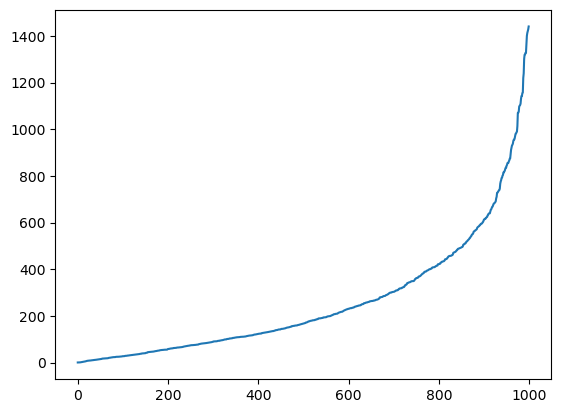

In [7]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

NTl = []
for n in range(1000):
    r = rd.random()
    NTl.append(-((60*3.053)/np.log(2))*np.log(1-r))
    
plt.plot(np.sort(NTl))

Exercise 10.5

In [32]:
from math import sin, sqrt
import random as rd

def f(x):
    return sin(1/(x*(2-x)))**2

N = 10000
points = 0

for i in range(N):
    x = 2*rd.random()
    y = rd.random()
    if y<f(x):
        points += 1
        
I = 2*points/N
        
print(I)
print(sqrt(I*(2-I))/sqrt(N))

1.4532
0.008914088624194847


In [45]:
N = 10000
h = 2/N
I = 0
f_2 = 0

for i in range(N):
    x = 2*rd.random()
    I += f(x)
    f_2 += f(x)**2    
print(I*h)
I /= N
f_2 /= N
print(h*sqrt(f_2 - I**2)/sqrt(N))

1.4470092220165887
5.262471236750838e-07


Exercise 10.7: Volume of a hypersphere

The volume $V$ in equation 10.33 is $2^{10}$, so
$$I=\frac{V}{N}\sum f(x_1,x_2,...,x_{10}).$$

In [10]:
import random as rd
import numpy as np

def f(r):
    if sum(r*r)<=1:
        return 1
    else:
        return 0
    
v = np.zeros(10,float)
I = 0
N = 10000000
V = 2**(10)

for i in range(N):
    for j in range(10):
        v[j] = 2*rd.random() - 1
    I += f(v)

print(V*I/N)

2.5520128


Exercise 10.8

From equation 10.39 we have
$$p(x)=\frac{w(x)}{\int_a^b w(x)dx},$$
where we have to use $w(x)=x^{-1/2}$. Let's calculate the integral in the denominator:
$$\int_0^1 x^{-1/2}dx=\frac{1}{1/2}x^{1/2}|_0^1=2.$$
So
$$p(x)=x^{-1/2}/2=\frac{1}{2x^{1/2}}.$$
To generate random numbers from this distribution we need $x(z)$:
$$z=\int_{0}^{x(z)}\frac{1}{2x^{1/2}}=\frac{1}{2}x^{1/2}2|_0^{x(z)}=x(z)^{1/2},$$
then
$$x(z)=z^2.$$

In [3]:
import random as rd
from math import exp

def f_w(x):
    return exp(x) + 1

I = 0
N = 100000000

for i in range(N):
    xi = rd.random()**2
    I += 1/f_w(xi)
    
print(I*2/N)

0.8389433744347253


Exercise 10.9: The Ising model

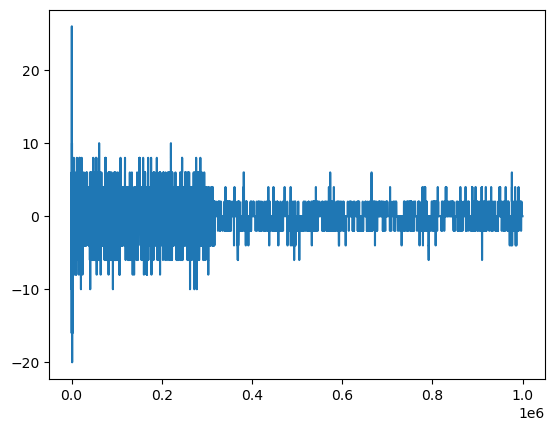

In [27]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

def En(G,J):
    N,M = G.shape
    E = 0
    E += (G[0:N-1,:]*G[1:N,:]).sum()
    E += (G[:,0:M-1]*G[:,1:M]).sum()
    return -J*E

grid = np.empty((20,20))
for i in range(20):
    for j in range(20):
            if rd.random() < 0.5:
                grid[i,j] = 1
            else:
                grid[i,j] = -1
                
J = 1
T = 1
Magnetization = grid.sum()
M = [Magnetization]
for s in range(1000000):
    i = rd.randrange(20)
    j = rd.randrange(20)

    oldE = En(grid,J)
    grid[i,j] *= -1
    newE = En(grid,J)
    dE = newE - oldE
    if rd.random()<np.exp(dE/T):
        oldE = newE
    else:
        grid[i,j] *= -1
    
    M.append(grid.sum())
    
plt.plot(M)

Exercise 10.10: Global minimum of a function

0.0005975819549381826


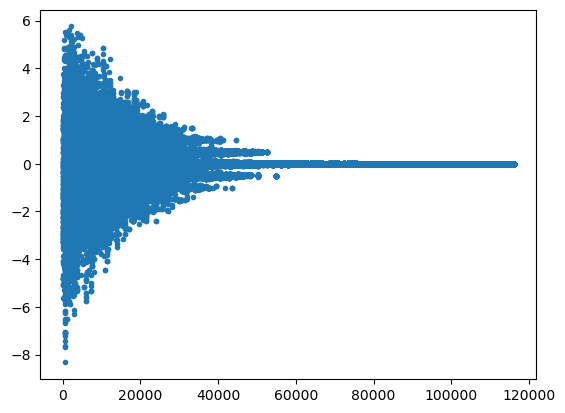

In [17]:
import random as rd
from math import cos,pi,exp,sqrt,log
import matplotlib.pyplot as plt

def f(x):
    return x**2 - cos(4*pi*x)

x = 2
Tmax = 11.0
Tmin = 1e-4
tau = 1e4

t = 0
T = Tmax
xpoints = []

while T>Tmin:
    t += 1
    T = Tmax*exp(-t/tau)
    theta = 2*pi*rd.random()
    r = sqrt(-2*log(1-rd.random()))
    delta = r*cos(theta)
    deltaD = f(x+delta)-f(x)
    if rd.random()<exp(-deltaD/T):
        x += delta
    xpoints.append(x)
    
plt.plot(xpoints,".")
print(x)

15.964635847226367


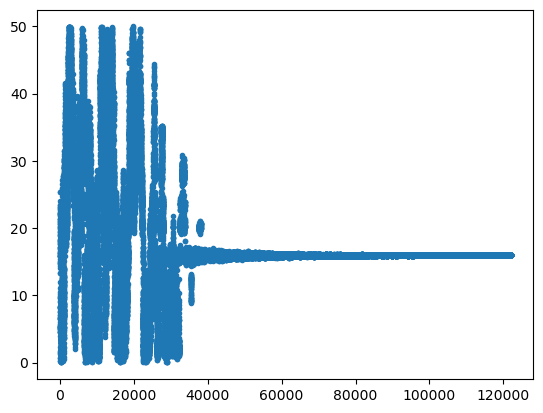

In [35]:
import random as rd
from math import cos,pi,exp,sqrt,log
import matplotlib.pyplot as plt

def f(x):
    return cos(x) + cos(sqrt(2)*x) + cos(sqrt(3)*x)

x = 25
Tmax = 20.0
Tmin = 1e-4
tau = 1e4

t = 0
T = Tmax
xpoints = []

while T>Tmin:
    t += 1
    T = Tmax*exp(-t/tau)
    theta = 2*pi*rd.random()
    r = sqrt(-2*log(1-rd.random()))
    delta = r*cos(theta)
    deltaD = f(x+delta)-f(x)
    if (x+delta)>0 and (x+delta)<50:
        if rd.random()<exp(-deltaD/T):
            x += delta
    xpoints.append(x)
    
plt.plot(xpoints,".")
print(x)

Exercise 10.11: The dimer covering problem

713.6614737788055

OverflowError: math range error

-23217.386297722016